In [1]:
#from google.colab import drive # remove the cell if not using colab
#drive.mount('/content/drive')

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report, accuracy_score
#base_path = Path('/content/drive/Shareddrives/KN Solvro/03. Projekty/Wakacyjne Wyzwanie 20256/ML/notebooki/1_Przetwarzanie i wizualizacja danych') # change path here!

# Treść zadania

## Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

# Modyfikacje zbioru - z poprzednich zajęć + podział na trening, test

In [3]:
#titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')
titanic_df = pd.read_csv('titanic.csv', index_col='PassengerId')
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Modyfikacje będą analogiczne jak robiłam poprzednio(z naniesionymi poprawkami). Operacje jak usunięcie kolumn, zamiana płci na 0, 1 oraz stworzenie kolumny family_on_board zrobiłam na całym zbiorze.

In [4]:
#usuwam 'Name', 'Ticket' oraz 'Cabin'
titanic_df = titanic_df.drop(columns = ['Name', 'Ticket', 'Cabin'])

In [5]:
#binarna płeć
is_sex_male = titanic_df['Sex'] == 'male'

titanic_df['is_male'] = is_sex_male * 1
titanic_df = titanic_df.drop( columns = ['Sex'])

In [6]:
#stworzenie family_on_board
titanic_df['family_on_board'] = titanic_df['SibSp'] + titanic_df['Parch']
titanic_df = titanic_df.drop(['SibSp', 'Parch'], axis=1)
titanic_df

,Survived,Pclass,Age,Fare,Embarked,is_male,family_on_board
PassengerId,,,,,,,
1,0,3,22.0,7.2500,S,1,1
2,1,1,38.0,71.2833,C,0,1
3,1,3,26.0,7.9250,S,0,0
4,1,1,35.0,53.1000,S,0,1
5,0,3,35.0,8.0500,S,1,0
...,...,...,...,...,...,...,...
887,0,2,27.0,13.0000,S,1,0
888,1,1,19.0,30.0000,S,0,0
889,0,3,NaN,23.4500,S,0,3


In [7]:
def distribution_fill(df, column, values, probs):
    missing = df[column].isna()
    df.loc[missing, column] = np.random.choice(
    values, size=missing.sum(), p=probs)

Resztę jak np. uzupełnianie rozkładem oraz encoding wykonałam osobno na zbiorze testowym oraz treningowym, aby zapobiec data leakage - z tym, że mam pytanie do osoby sprawdzającej czy ja to na pewno poprawnie zrobiłam (dla przykładu kolumna 'Age' w zbiorze testowym jest uzupełniona na podstawie 'Age' w zbiorze treningowym). Nie jestem pewna i przyjmę wszelkie uwagi w tym temacie.

Dodatkowo wykonana normalizacja za pomocą StandardScaler

In [8]:
y = titanic_df['Survived']
X = titanic_df.drop(columns=['Survived'])

#podział danych
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

#statystyki zbioru treningowego
fare_median = X_train.groupby('Pclass')['Fare'].median()
embarked_mode = X_train['Embarked'].mode()[0]

age_dist = X_train['Age'].value_counts(normalize=True)
age_values = age_dist.index
age_probs = age_dist.values

#uzupełnianie zbioru treningowego
distribution_fill(X_train, 'Age', age_values, age_probs) 

X_train['Fare'] = X_train['Fare'].fillna(X_train['Pclass'].map(fare_median))
X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)

#uzupełnienie testu - statystyką z treningu
X_test['Fare'] = X_test['Fare'].fillna(X_test['Pclass'].map(fare_median))
X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)
distribution_fill(X_test, 'Age', age_values, age_probs) 

#poprawka Fare
train_fare_median = X_train['Fare'].median()
X_train.loc[X_train['Fare'] > 300, 'Fare'] = train_fare_median
X_test.loc[X_test['Fare'] > 300, 'Fare'] = train_fare_median

#normalizacja
cols_to_scale = ['Age', 'Fare', 'Pclass', 'family_on_board']
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

#encoding treningowego
X_train_enc = pd.get_dummies(X_train, columns=['Embarked'], dtype=int)
X_train = X_train_enc
#encoding testowego
X_test_enc = pd.get_dummies(X_test, columns=['Embarked'], dtype=int)
X_test = X_test_enc

Tak wygldają dane zbioru testowego

In [9]:
X_test.head()

,Pclass,Age,Fare,is_male,family_on_board,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
863,-1.555593,1.196112,-0.123724,0,-0.575156,0,0,1
224,0.836593,-0.200069,-0.547725,1,-0.575156,0,0,1
85,-0.359500,-0.864917,-0.486495,0,-0.575156,0,0,1
681,0.836593,-0.864917,-0.544100,0,-0.575156,0,1,0
536,-0.359500,-1.529765,-0.116181,0,0.754425,0,0,1


# Baseline

Wykonałam dummyclassifiera, aby móc porównać przyszłe modele.

In [10]:
#test dummy clasifier
model = DummyClassifier(strategy = 'uniform')
model.fit(X_train, y_train) # uczenie
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.62      0.49      0.55       106
           1       0.43      0.56      0.49        73

    accuracy                           0.52       179
   macro avg       0.53      0.53      0.52       179
weighted avg       0.54      0.52      0.52       179



array([[52, 54],
       [32, 41]], dtype=int64)

In [11]:
print(f"Skuteczność (Accuracy) modelu Dummy Classifier: {accuracy_score(y_test, y_pred):.4f}\n")

Skuteczność (Accuracy) modelu Dummy Classifier: 0.5196



# Model KNN

Następnie zdecydowałam się na wykorzystanie modelu KNN.

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def confusion_matrix(model, X_test, y_test):
    best = model.best_estimator_
    ConfusionMatrixDisplay.from_estimator(
    best, X_test, y_test, cmap='Blues', values_format='d')
    plt.title('Macierz pomyłek')
    plt.show()

In [42]:
from sklearn.model_selection import GridSearchCV

siatka_KNN = {
    'n_neighbors':         [2, 3, 5, 10, 20],
    'metric':         ['euclidean', 'manhattan', 'cosine', 'minkowski']
}

szukaj_KNN = GridSearchCV(
    KNeighborsClassifier(),
    siatka_KNN,
    cv = 5,
    scoring='accuracy'
)
#nauka modelu
szukaj_KNN.fit(X_train, y_train)

print("najlepsze ustawienia:", szukaj_KNN.best_params_)
print("wynik kroswalidacji: ", round(szukaj_KNN.best_score_, 3))
print("wynik na tescie:     ", round(szukaj_KNN.score(X_test, y_test), 3))

najlepsze ustawienia: {'metric': 'manhattan', 'n_neighbors': 10}
wynik kroswalidacji:  0.829
wynik na tescie:      0.754


Tutaj skuteczność jest wyższa niż modelu dummy, czyli ewidentnie działa lepiej. Najlepszą opcją okazała się metryka manhattan z 10 sąsiadami. Macierz pomyłek poniżej pokazuje iż najczęstszym błędem modelu jest przypisywanie danej osobie tego iż nie przeżyła, gdy w rzeczywistości ta osoba przeżyła.

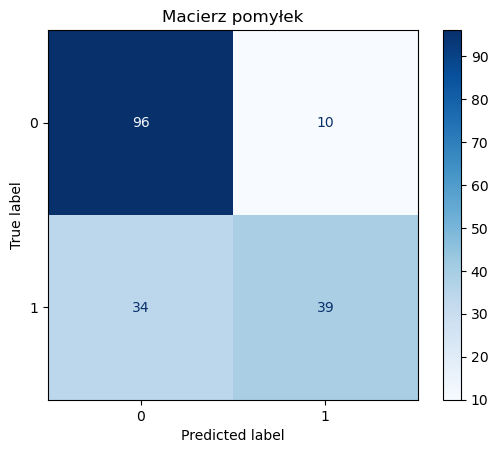

In [43]:
confusion_matrix(szukaj_KNN, X_test, y_test)

Następnie chciałam przekonać się czy któreś cechy nie są modelowi potrzebne, więc wykorzystalam permutation importance, które sprawdza ważność powiązania cechy z wynikiem końcowym. Działa to poprzez przemieszanie wartości danej cechy oraz sprawdzenie jak bardzo wynik końcowy się zmienił. Im bardziej jakość predykcji się pogorszyła tym mniej ważna jest ta cecha.

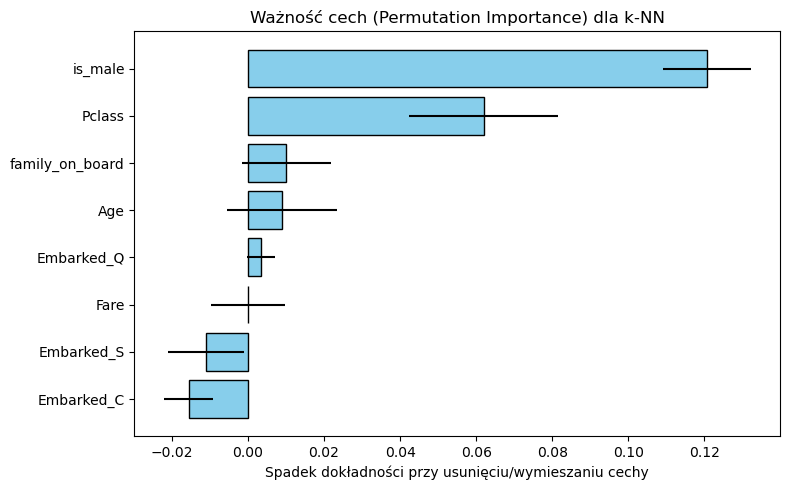

In [44]:
from sklearn.inspection import permutation_importance

best_knn  = szukaj_KNN.best_estimator_

wyniki_waznosci = permutation_importance(
    best_knn, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy'
)
nazwy_cech = X_test.columns

df_waznosc = pd.DataFrame({
    'Cecha': nazwy_cech,
    'Ważność (średnia)': wyniki_waznosci.importances_mean,
    'Odchylenie standardowe': wyniki_waznosci.importances_std,
}).sort_values(by='Ważność (średnia)', ascending=True)

# Rysujemy wykres
plt.figure(figsize=(8, 5))
plt.barh(df_waznosc['Cecha'], df_waznosc['Ważność (średnia)'], xerr=df_waznosc['Odchylenie standardowe'], color='skyblue', edgecolor='black')
plt.title('Ważność cech (Permutation Importance) dla k-NN')
plt.xlabel('Spadek dokładności przy usunięciu/wymieszaniu cechy')
plt.tight_layout()
plt.show()

Na wykresie widoczne pogorszenie w Embarked_S i Embarked_C oraz dokładnie zerowy wpływ Fare na wynik końcowy, zatem do tego modelu kolumny te zostały usunięte oraz na nowo przetestowane działanie.

In [47]:
import copy
trash_cols = [ 'Fare', 'Embarked_S', 'Embarked_C']
X_train_KNN = X_train.copy()
y_train_KNN = y_train.copy()
X_test_KNN = X_test.copy()
y_test_KNN = y_test.copy()

X_train_KNN = X_train_KNN.drop(columns=trash_cols)
X_test_KNN = X_test_KNN.drop(columns=trash_cols)

In [48]:
#nauka modelu
szukaj_KNN.fit(X_train_KNN, y_train_KNN)

print("najlepsze ustawienia:", szukaj_KNN.best_params_)
print("wynik kroswalidacji: ", round(szukaj_KNN.best_score_, 3))
print("wynik na tescie:     ", round(szukaj_KNN.score(X_test_KNN, y_test_KNN), 3))

najlepsze ustawienia: {'metric': 'manhattan', 'n_neighbors': 20}
wynik kroswalidacji:  0.833
wynik na tescie:      0.765


Wynik końcowy po poprawkach nie jest dużo wyższy od poprzedniego, więc kolumny te nie miały aż takiego wpływu, ale tutaj najlepszą opcją jest metryka manhattan i n_neighbours 20

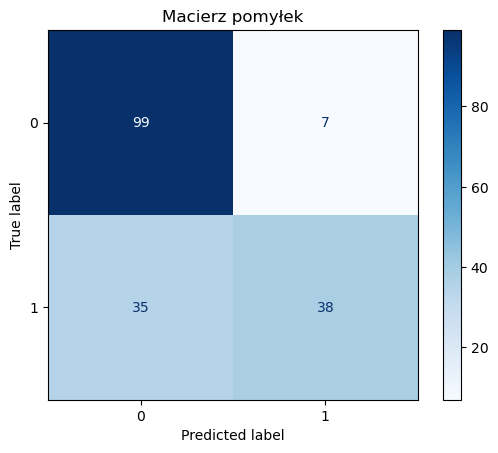

In [49]:
confusion_matrix(szukaj_KNN, X_test_KNN, y_test_KNN)

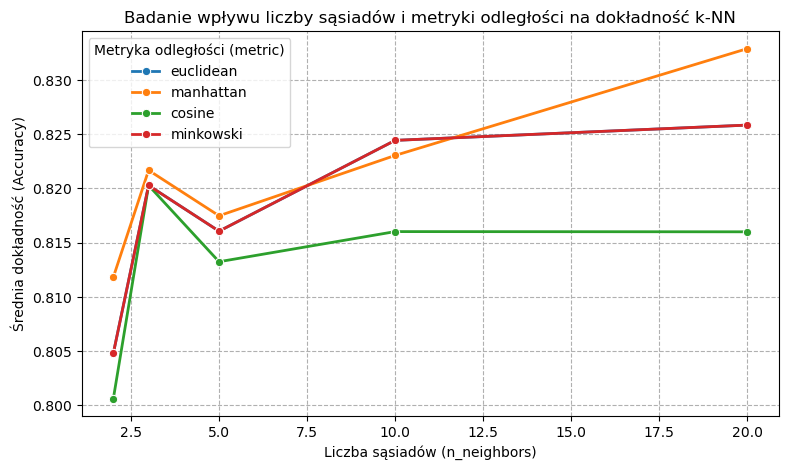

In [66]:
import seaborn as sns
wyniki_KNN = pd.DataFrame(szukaj_KNN.cv_results_)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=wyniki_KNN,
    x='param_n_neighbors',
    y='mean_test_score',
    hue='param_metric',
    marker='o',
    linewidth=2,
)

plt.title(
    'Badanie wpływu liczby sąsiadów i metryki odległości na dokładność k-NN'
)
plt.xlabel('Liczba sąsiadów (n_neighbors)')
plt.ylabel('Średnia dokładność (Accuracy)')
plt.grid(True, linestyle='--')
plt.legend(title='Metryka odległości (metric)')
plt.show()

Wykres ze wartościami accuracy dla konkretnych hiperparametrów przedstawia, że najgorsze wyniki były dla n_neighbours=2, zaskakujący spadek przy wartości 5 oraz potem wzrost przy 10. Większość metryk przy zmianie z 10 na 20 nie wykazało dużych różnic, ale metryka manhattan podczas tej zmiany wskoczyła nad wartości matryki minkowski.

metryka euclidesowa w tym przypadku pokrywa sie z minkowski, dlatego jej nie widać.

# Model SVM

W następnym kroku przetestowałam model SVM, z siatką hiperparametrów kernela opcje: linear, poly, rbf, sigmoid.
Tutaj najlepszą opcją jest kernel rbf.

In [52]:
from sklearn.svm import SVC
siatka_SVC = { 'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
             'C': [0.01, 0.1, 1, 10, 100]}

szukaj_SVC = GridSearchCV(
    SVC(),
    siatka_SVC,
    cv = 5,
    scoring='accuracy'
)

szukaj_SVC.fit(X_train, y_train)

print("najlepsze ustawienia:", szukaj_SVC.best_params_)
print("wynik kroswalidacji: ", round(szukaj_SVC.best_score_, 3))
print("wynik na tescie:     ", round(szukaj_SVC.score(X_test, y_test), 3))

najlepsze ustawienia: {'C': 10, 'kernel': 'rbf'}
wynik kroswalidacji:  0.827
wynik na tescie:      0.76


Wyniki najlepsze są dla hiperparametrów C = 10 oraz kerner = rbf. 

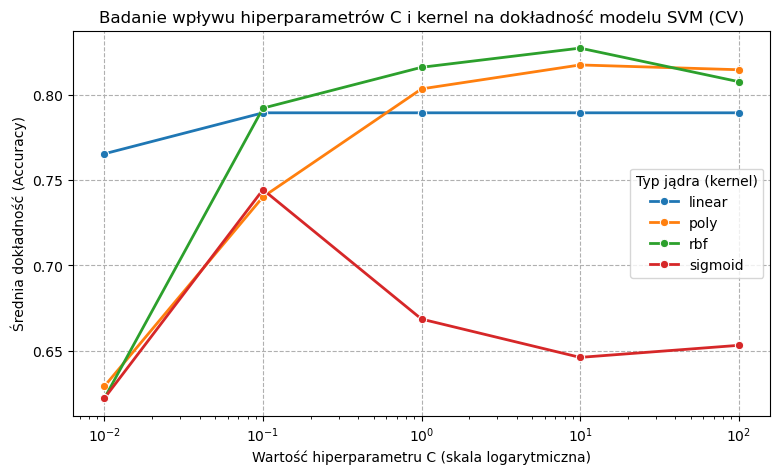

In [56]:
import seaborn as sns
wyniki_SVM = pd.DataFrame(szukaj_SVC.cv_results_)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=wyniki_SVM,
    x='param_C',
    y='mean_test_score',
    hue='param_kernel',
    marker='o',
    linewidth=2,
)
plt.xscale('log')  # Skala logarytmiczna jest idealna dla parametru C
plt.title(
    'Badanie wpływu hiperparametrów C i kernel na dokładność modelu SVM (CV)'
)
plt.xlabel('Wartość hiperparametru C (skala logarytmiczna)')
plt.ylabel('Średnia dokładność (Accuracy)')
plt.grid(True, linestyle='--')
plt.legend(title='Typ jądra (kernel)')
plt.show()

na wykresie jądro liniowe przy zmianach wartości C nie wykazuje dużych zmian. Reszta parametrów ma duże różnice podczas modyfikacji C. Sigmoid zadziałał najlepiej z wartością 1/10, natomiast poly oraz rbf właśnie z wartością 10, przy czym rbf był delikatnie lepszy.

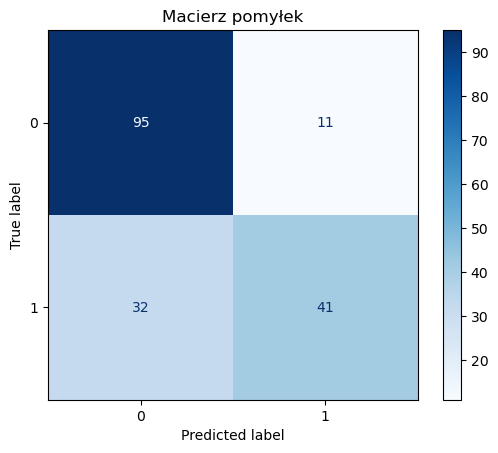

In [69]:
confusion_matrix(szukaj_SVC, X_test, y_test)

W macierzy pomyłek widać iż błędy są bardzo podobne jak modelu KNN. Zakłada on że osoba nie przeżyła, gdy naprawdę przeżyła.

# Model drzewa decyzyjnego

Kolejnym modelem jest drzewo decyzyjne z hiperparametrami kryterium oraz maksymalna głębokość

In [15]:
from sklearn.tree import DecisionTreeClassifier

siatka_tree = { 'criterion': ["gini", "entropy", "log_loss"],
                'max_depth': [2, 3, 4] }

szukaj_tree = GridSearchCV(
    DecisionTreeClassifier(),
    siatka_tree,
    cv = 5,
    scoring='accuracy'
)

szukaj_tree.fit(X_train, y_train)
print("najlepsze ustawienia:", szukaj_tree.best_params_)
print("wynik kroswalidacji: ", round(szukaj_tree.best_score_, 3))
print("wynik na tescie:     ", round(szukaj_tree.score(X_test, y_test), 3))

najlepsze ustawienia: {'criterion': 'gini', 'max_depth': 3}
wynik kroswalidacji:  0.808
wynik na tescie:      0.799


Wyniki najlepsze zostały osiągnięte dla gini przy głębokości 3. Poniżej wykres średniej wartości accuracy dla różnych hiperparametrów

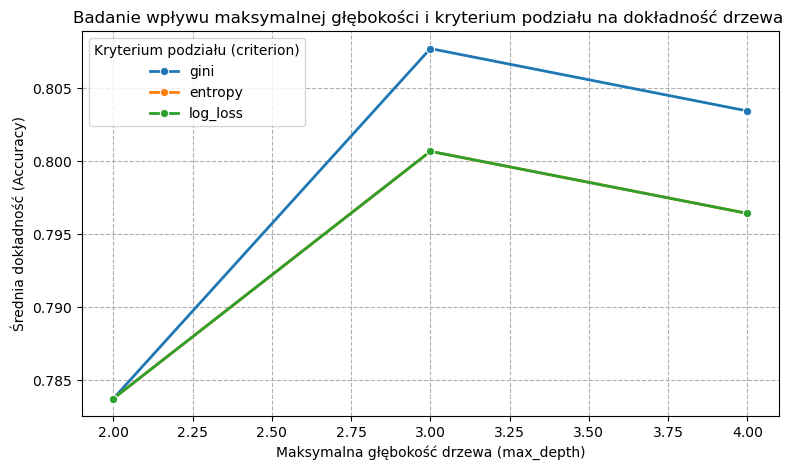

In [73]:
wyniki_tree = pd.DataFrame(szukaj_tree.cv_results_)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=wyniki_tree,
    x='param_max_depth',
    y='mean_test_score',
    hue='param_criterion',
    marker='o',
    linewidth=2,
)

plt.title(
    'Badanie wpływu maksymalnej głębokości i kryterium podziału na dokładność'
    ' drzewa '
)
plt.xlabel('Maksymalna głębokość drzewa (max_depth)')
plt.ylabel('Średnia dokładność (Accuracy)')
plt.grid(True, linestyle='--')
plt.legend(title='Kryterium podziału (criterion)')
plt.show()

Tutaj przy głębokości 2 najniższe wyniki, natomiast przy 3 najwyższe, a potem jest spadek przy 4.

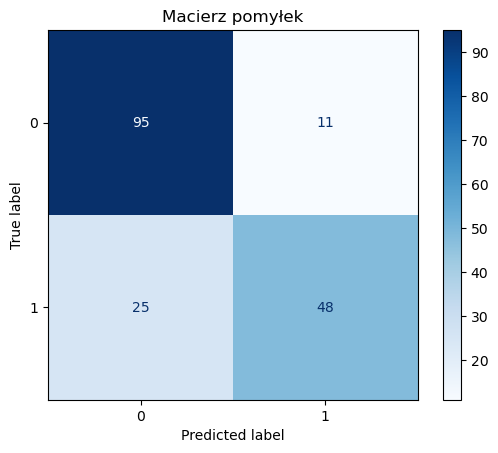

In [74]:
confusion_matrix(szukaj_tree, X_test, y_test)

Popełniane błędy analogiczne jak w poprzednich modelach.

# Podsumowanie

In [77]:
from sklearn.model_selection import cross_val_score
for nazwa, m in [
    ("Dummy      ", DummyClassifier(strategy='uniform')),
    ("KNN        ", KNeighborsClassifier(n_neighbors=szukaj_KNN.best_params_['n_neighbors'], metric=szukaj_KNN.best_params_['metric'])),
    ("SVM        ", SVC(C=szukaj_SVC.best_params_['C'], kernel=szukaj_SVC.best_params_['kernel'])),
    ("Drzewo     ", DecisionTreeClassifier(max_depth=szukaj_tree.best_params_['max_depth'], criterion=szukaj_tree.best_params_['criterion'])),
]:
    w = cross_val_score(m, X_test, y_test, cv=5)
    print(f"{nazwa} {w.mean():.3f} +/- {w.std():.3f}")

Dummy       0.547 +/- 0.061
KNN         0.732 +/- 0.050
SVM         0.732 +/- 0.058
Drzewo      0.749 +/- 0.046


Na tym zbiorze najlepiej zadziałało drzewo decyzyjne z hiperparametrami 'criterion': 'gini', 'max_depth': 3. 

Poniżej takie najważniejsze moim zdaniem wnioski z pracy:
- Eda to jest jeden z najważniejszych etapów uczenia maszynowego.
- standaryzacja danych jest istotna w wielu modelach i trzeba o niej pamiętać
- akurat w przypadku tego zbioru danych różnice między wybranymi modelami nie były ogromne, natomiast warto testować różne hiperparametry.
- bardzo fajna wydaje mi się crosswalidacja
- to w sumie tyle. Nie jestem polonistą żeby się rozdrabniać nad takimi rzeczami. Miłego dnia